# ATM Breakdown Prediction - Notebook 3: Model Training & Comparison

This notebook trains and compares multiple models for ATM failure prediction.

## Objectives
1. Train baseline models
2. Train tree-based models (LightGBM, XGBoost, CatBoost)
3. Handle class imbalance
4. Compare model performance
5. Analyze feature importance
6. Save trained models

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, f1_score, fbeta_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Tree-based models
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

print("Libraries imported successfully!")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version: {xgb.__version__}")

Libraries imported successfully!
LightGBM version: 4.7.0
XGBoost version: 3.4.1


## 1. Load Processed Data

In [6]:
# Load processed datasets
PROCESSED_DIR = Path('data/processed')

print("Loading processed datasets...")
df_train = pd.read_csv(PROCESSED_DIR / 'train_chronological.csv', parse_dates=['timestamp'])
df_val = pd.read_csv(PROCESSED_DIR / 'val_chronological.csv', parse_dates=['timestamp'])
df_test = pd.read_csv(PROCESSED_DIR / 'test_chronological.csv', parse_dates=['timestamp'])

# Load feature columns
with open(PROCESSED_DIR / 'feature_columns.txt', 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"\nTrain: {df_train.shape}")
print(f"Validation: {df_val.shape}")
print(f"Test: {df_test.shape}")
print(f"\nFeatures: {len(feature_cols)}")

# Prepare X and y
X_train = df_train[feature_cols]
y_train = df_train['fails_within_next_30m']

X_val = df_val[feature_cols]
y_val = df_val['fails_within_next_30m']

X_test = df_test[feature_cols]
y_test = df_test['fails_within_next_30m']

print(f"\nClass distribution:")
print(f"Train - Failures: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Val   - Failures: {y_val.sum():,} ({y_val.mean()*100:.4f}%)")
print(f"Test  - Failures: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")

Loading processed datasets...

Train: (406772, 145)
Validation: (87165, 145)
Test: (87166, 145)

Features: 139

Class distribution:
Train - Failures: 2,059 (0.5062%)
Val   - Failures: 407 (0.4669%)
Test  - Failures: 318 (0.3648%)


## 2. Baseline Models

In [7]:
# Baseline 1: Always predict no failure
baseline_always_no = np.zeros(len(y_val))
baseline_ap = average_precision_score(y_val, baseline_always_no)

print("=" * 70)
print("BASELINE MODELS")
print("=" * 70)
print(f"\nBaseline 1: Always predict no failure")
print(f"  PR-AUC: {baseline_ap:.6f}")
print(f"  (This is the minimum score to beat)")

# Store results
results = {
    'Baseline (Always No)': {
        'pr_auc': baseline_ap,
        'model': None
    }
}

BASELINE MODELS

Baseline 1: Always predict no failure
  PR-AUC: 0.004669
  (This is the minimum score to beat)


## 3. Logistic Regression

In [9]:
# Keep only numeric columns for modeling
numeric_features = X_train.select_dtypes(include=[np.number]).columns

X_train_num = X_train[numeric_features]
X_val_num = X_val[numeric_features]

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_val_scaled = scaler.transform(X_val_num)

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nClass weights: {class_weight_dict}")

# Train logistic regression
print("\nTraining logistic regression...")
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_val_pred_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Evaluate
lr_pr_auc = average_precision_score(y_val, y_val_pred_lr)
lr_roc_auc = roc_auc_score(y_val, y_val_pred_lr)

print(f"\nLogistic Regression Results:")
print(f"  PR-AUC: {lr_pr_auc:.6f}")
print(f"  ROC-AUC: {lr_roc_auc:.6f}")

results['Logistic Regression'] = {
    'pr_auc': lr_pr_auc,
    'roc_auc': lr_roc_auc,
    'model': lr_model,
    'scaler': scaler
}


Class weights: {0: np.float64(0.5025437779364637), 1: np.float64(98.7790189412336)}

Training logistic regression...

Logistic Regression Results:
  PR-AUC: 0.529657
  ROC-AUC: 0.943380


## 4. LightGBM

In [11]:
# Convert any object/string columns to 'category' dtype so LightGBM can handle them
for col in X_train.select_dtypes(include=['object', 'string']).columns:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

# Alternatively, if you want to drop them entirely:
# non_numeric_cols = X_train.select_dtypes(include=['object', 'string']).columns
# X_train = X_train.drop(columns=non_numeric_cols)
# X_val = X_val.drop(columns=non_numeric_cols)

# Re-create datasets after fixing column types
lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

# Train
print("\nTraining LightGBM...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# Predict
y_val_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)

# Evaluate
lgb_pr_auc = average_precision_score(y_val, y_val_pred_lgb)
lgb_roc_auc = roc_auc_score(y_val, y_val_pred_lgb)

print(f"\nLightGBM Results:")
print(f"  Best iteration: {lgb_model.best_iteration}")
print(f"  PR-AUC: {lgb_pr_auc:.6f}")
print(f"  ROC-AUC: {lgb_roc_auc:.6f}")

results['LightGBM'] = {
    'pr_auc': lgb_pr_auc,
    'roc_auc': lgb_roc_auc,
    'model': lgb_model
}


Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	train's auc: 0.997075	val's auc: 0.943475

LightGBM Results:
  Best iteration: 31
  PR-AUC: 0.456955
  ROC-AUC: 0.943475


## 5. XGBoost

In [17]:
print("\n" + "=" * 70)
print("XGBOOST")
print("=" * 70)

# Safely handle categorical and boolean columns that contain NaNs or booleans
for col in X_train.columns:
    if pd.api.types.is_categorical_dtype(X_train[col]) or X_train[col].dtype == 'object':
        # Convert to string, filling NaNs with a safe 'Missing' label to prevent crashes
        X_train[col] = X_train[col].astype(object).fillna('Missing').astype(str).astype('category')
        X_val[col] = X_val[col].astype(object).fillna('Missing').astype(str).astype('category')
    elif X_train[col].dtype == 'bool' or str(X_train[col].dtype) == 'boolean':
        # Fill missing booleans with False, then convert to int
        X_train[col] = X_train[col].fillna(False).astype(int)
        X_val[col] = X_val[col].fillna(False).astype(int)

# XGBoost parameters
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'tree_method': 'hist'
}

# Create DMatrix 
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

# Train
print("\nTraining XGBoost...")
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predict
y_val_pred_xgb = xgb_model.predict(dval)

# Evaluate
xgb_pr_auc = average_precision_score(y_val, y_val_pred_xgb)
xgb_roc_auc = roc_auc_score(y_val, y_val_pred_xgb)

print(f"\nXGBoost Results:")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"  PR-AUC: {xgb_pr_auc:.6f}")
print(f"  ROC-AUC: {xgb_roc_auc:.6f}")

results['XGBoost'] = {
    'pr_auc': xgb_pr_auc,
    'roc_auc': xgb_roc_auc,
    'model': xgb_model
}


XGBOOST

Training XGBoost...
[0]	train-auc:0.94950	val-auc:0.92941
[58]	train-auc:0.99754	val-auc:0.95833

XGBoost Results:
  Best iteration: 8
  PR-AUC: 0.562419
  ROC-AUC: 0.958326


## 6. CatBoost

In [19]:
print("\n" + "=" * 70)
print("CATBOOST")
print("=" * 70)

# Automatically identify category or object columns to pass to CatBoost
cat_features_list = list(X_train.select_dtypes(include=['category', 'object', 'bool']).columns)

# CatBoost model
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=100,
    early_stopping_rounds=50
)

# Train with explicit cat_features
print("\nTraining CatBoost...")
cat_model.fit(
    X_train, y_train,
    cat_features=cat_features_list,
    eval_set=(X_val, y_val),
    verbose=100
)

# Predict
y_val_pred_cat = cat_model.predict_proba(X_val)[:, 1]

# Evaluate
cat_pr_auc = average_precision_score(y_val, y_val_pred_cat)
cat_roc_auc = roc_auc_score(y_val, y_val_pred_cat)

print(f"\nCatBoost Results:")
print(f"  Best iteration: {cat_model.best_iteration_}")
print(f"  PR-AUC: {cat_pr_auc:.6f}")
print(f"  ROC-AUC: {cat_roc_auc:.6f}")

results['CatBoost'] = {
    'pr_auc': cat_pr_auc,
    'roc_auc': cat_roc_auc,
    'model': cat_model
}


CATBOOST

Training CatBoost...
0:	learn: 0.6236305	test: 0.6237591	best: 0.6237591 (0)	total: 362ms	remaining: 3m
100:	learn: 0.1403447	test: 0.1912318	best: 0.1897417 (80)	total: 31.8s	remaining: 2m 5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1897417294
bestIteration = 80

Shrink model to first 81 iterations.

CatBoost Results:
  Best iteration: 80
  PR-AUC: 0.498484
  ROC-AUC: 0.965954


## 7. Model Comparison

In [20]:
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'PR-AUC': metrics['pr_auc'],
        'ROC-AUC': metrics.get('roc_auc', np.nan)
    }
    for name, metrics in results.items()
]).sort_values('PR-AUC', ascending=False)

print("\n" + "=" * 70)
print("MODEL COMPARISON (Validation Set)")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")
print(f"PR-AUC: {comparison_df.iloc[0]['PR-AUC']:.6f}")


MODEL COMPARISON (Validation Set)
               Model   PR-AUC  ROC-AUC
             XGBoost 0.562419 0.958326
 Logistic Regression 0.529657 0.943380
            CatBoost 0.498484 0.965954
            LightGBM 0.456955 0.943475
Baseline (Always No) 0.004669      NaN

Best model: XGBoost
PR-AUC: 0.562419


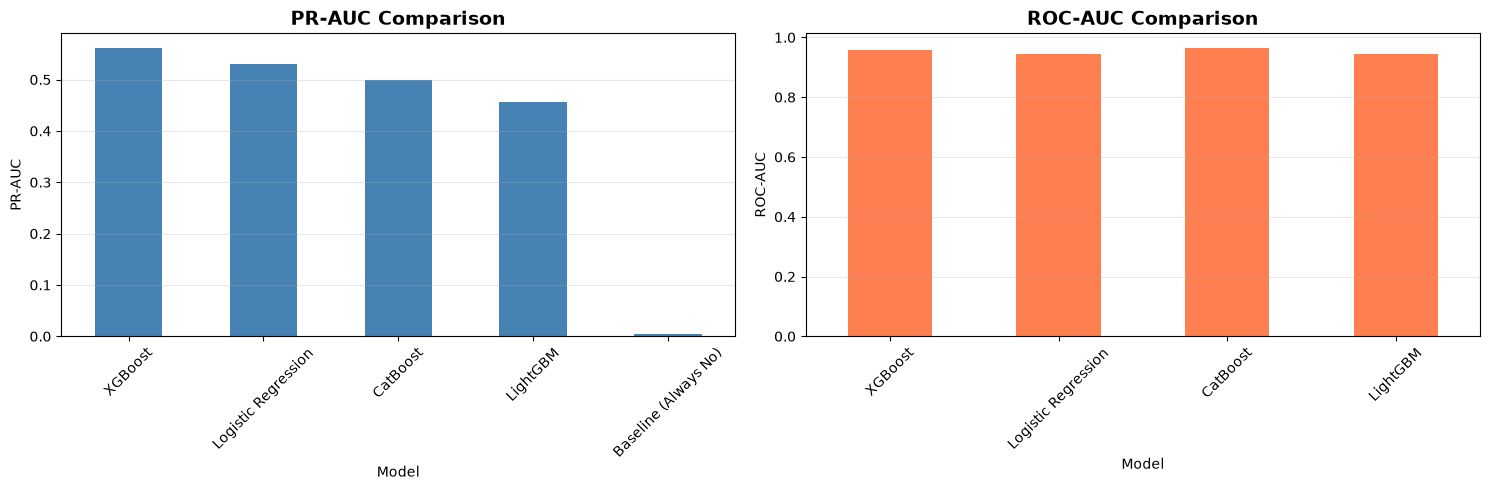

Figure saved: C:\Users\154064\Desktop\ATM\notebooks\figures\03_model_comparison.png


In [22]:
from pathlib import Path

# Ensure figures directory exists
fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PR-AUC comparison
comparison_df.plot(x='Model', y='PR-AUC', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('PR-AUC Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('PR-AUC')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# ROC-AUC comparison
comparison_df[comparison_df['ROC-AUC'].notna()].plot(x='Model', y='ROC-AUC', kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ROC-AUC')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

output_path = fig_dir / '03_model_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {output_path.resolve()}")

## 8. Feature Importance (Best Model)

In [23]:
# Get feature importance from best tree model
if best_model_name == 'LightGBM':
    importance = lgb_model.feature_importance(importance_type='gain')
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
elif best_model_name == 'XGBoost':
    importance = xgb_model.get_score(importance_type='gain')
    feature_importance_df = pd.DataFrame([
        {'feature': k, 'importance': v}
        for k, v in importance.items()
    ]).sort_values('importance', ascending=False)
    
elif best_model_name == 'CatBoost':
    importance = cat_model.get_feature_importance()
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance
    }).sort_values('importance', ascending=False)

print("\n" + "=" * 70)
print(f"TOP 20 FEATURES ({best_model_name})")
print("=" * 70)
print(feature_importance_df.head(20).to_string(index=False))


TOP 20 FEATURES (XGBoost)
                                             feature   importance
                        power_battery_health_percent 75805.375000
        dispenser_failed_pick_count_rolling_mean_30m 71966.171875
         dispenser_failed_pick_count_rolling_max_30m 48504.066406
          software_cpu_usage_percent_rolling_max_30m  4564.075684
             temperature_time_above_warning_temp_min  3420.788574
          software_cpu_usage_percent_rolling_max_15m  3294.076660
                            monitoring_timeout_count  2139.427246
monitoring_failed_transaction_count_rolling_mean_15m  2124.953857
        dispenser_failed_pick_count_rolling_mean_15m  2028.038452
                         dispenser_jam_warning_count  1573.193359
                 network_latency_ms_rolling_max_180m  1554.027832
                network_latency_ms_rolling_mean_180m  1517.775391
              power_input_voltage_v_rolling_std_120m  1466.771240
         temperature_cabinet_temp_c_rolling_max_1

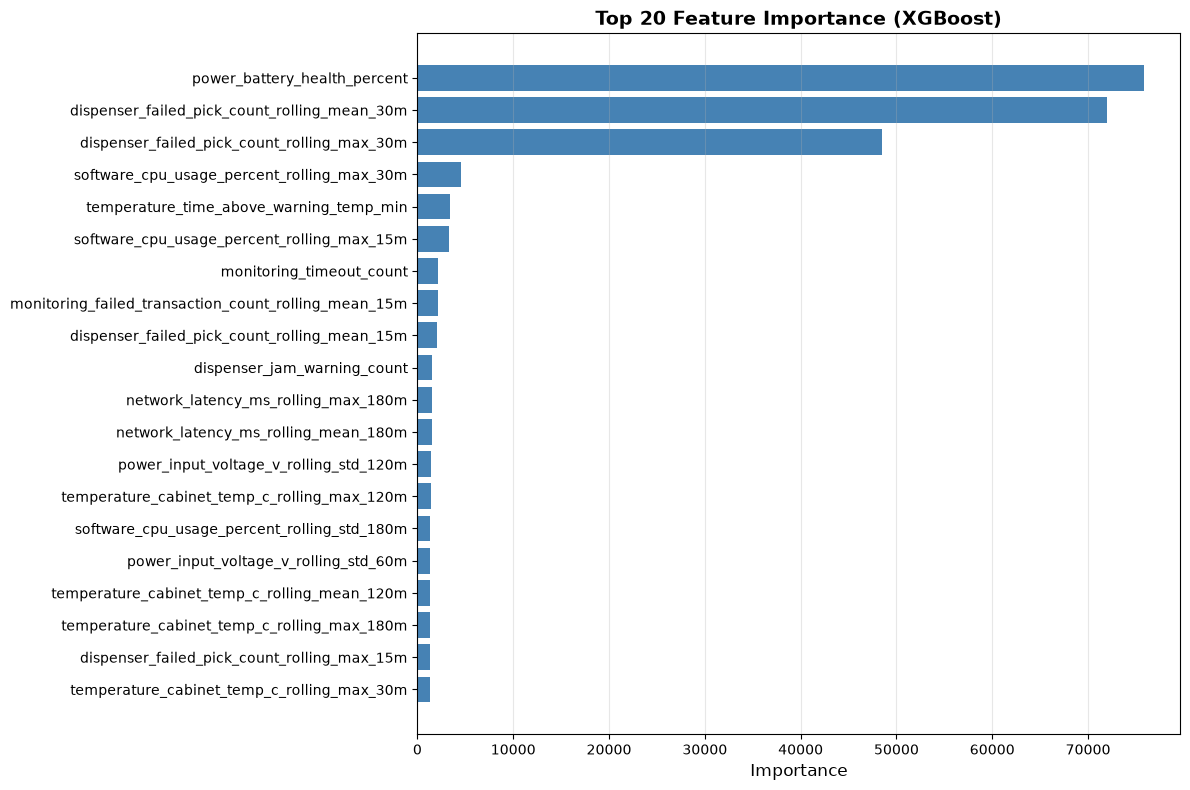

Figure saved: C:\Users\154064\Desktop\ATM\notebooks\figures\03_feature_importance.png


In [25]:
from pathlib import Path

# Ensure figures directory exists
fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 8))

top_features = feature_importance_df.head(20)
ax.barh(range(len(top_features)), top_features['importance'], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=12)
ax.set_title(f'Top 20 Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()

output_path = fig_dir / '03_feature_importance.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {output_path.resolve()}")

## 9. Save Models

In [26]:
# Create models directory
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Saving models...")

# Save all models
if 'Logistic Regression' in results:
    joblib.dump(results['Logistic Regression']['model'], MODELS_DIR / 'logistic_regression.pkl')
    joblib.dump(results['Logistic Regression']['scaler'], MODELS_DIR / 'scaler.pkl')
    print("  - Logistic Regression saved")

if 'LightGBM' in results:
    results['LightGBM']['model'].save_model(str(MODELS_DIR / 'lightgbm_model.txt'))
    print("  - LightGBM saved")

if 'XGBoost' in results:
    results['XGBoost']['model'].save_model(str(MODELS_DIR / 'xgboost_model.json'))
    print("  - XGBoost saved")

if 'CatBoost' in results:
    results['CatBoost']['model'].save_model(str(MODELS_DIR / 'catboost_model.cbm'))
    print("  - CatBoost saved")

# Save feature columns
with open(MODELS_DIR / 'feature_columns.txt', 'w') as f:
    f.write('\n'.join(feature_cols))
print("  - Feature columns saved")

# Save model comparison results
comparison_df.to_csv(MODELS_DIR / 'model_comparison.csv', index=False)
print("  - Model comparison saved")

# Save feature importance
feature_importance_df.to_csv(MODELS_DIR / 'feature_importance.csv', index=False)
print("  - Feature importance saved")

# Save metadata
metadata = {
    'training_date': datetime.now().isoformat(),
    'best_model': best_model_name,
    'best_pr_auc': float(comparison_df.iloc[0]['PR-AUC']),
    'n_features': len(feature_cols),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'failure_rate_train': float(y_train.mean()),
    'failure_rate_val': float(y_val.mean()),
    'failure_rate_test': float(y_test.mean())
}

with open(MODELS_DIR / 'training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("  - Metadata saved")

print(f"\nAll models saved to: {MODELS_DIR}")

Saving models...
  - Logistic Regression saved
  - LightGBM saved
  - XGBoost saved
  - CatBoost saved
  - Feature columns saved
  - Model comparison saved
  - Feature importance saved
  - Metadata saved

All models saved to: models


## 10. Summary

In [27]:
print("=" * 70)
print("MODEL TRAINING SUMMARY")
print("=" * 70)

print(f"""
Models Trained:
1. Baseline (Always No Failure)
2. Logistic Regression
3. LightGBM
4. XGBoost
5. CatBoost

Best Model: {best_model_name}
Best PR-AUC: {comparison_df.iloc[0]['PR-AUC']:.6f}

Class Imbalance Handling:
- Scale pos weight: {scale_pos_weight:.2f}
- Class weights applied

Top 5 Most Important Features:
""")

for idx, row in feature_importance_df.head(5).iterrows():
    print(f"{idx+1}. {row['feature']}")

print(f"""
Next Steps:
1. Evaluate on test set (chronological)
2. Evaluate on unseen ATM test set
3. Select operating thresholds
4. Create inference package
""")

print("\n" + "=" * 70)
print("Notebook 3 Complete! Proceed to Notebook 4: Evaluation")
print("=" * 70)

MODEL TRAINING SUMMARY

Models Trained:
1. Baseline (Always No Failure)
2. Logistic Regression
3. LightGBM
4. XGBoost
5. CatBoost

Best Model: XGBoost
Best PR-AUC: 0.562419

Class Imbalance Handling:
- Scale pos weight: 196.56
- Class weights applied

Top 5 Most Important Features:

8. power_battery_health_percent
68. dispenser_failed_pick_count_rolling_mean_30m
70. dispenser_failed_pick_count_rolling_max_30m
73. software_cpu_usage_percent_rolling_max_30m
15. temperature_time_above_warning_temp_min

Next Steps:
1. Evaluate on test set (chronological)
2. Evaluate on unseen ATM test set
3. Select operating thresholds
4. Create inference package


Notebook 3 Complete! Proceed to Notebook 4: Evaluation
